## Tesla Deliveries & Production Forecasting

### Objective
Build an end-to-end Machine Learning pipeline using Tesla's Deliveries and Production dataset (2015–2025).

#### Tasks
- Data Collection

- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting
- Model Evaluation

# 1. Data Loading

In this section, the required libraries are imported and the Tesla deliveries dataset is loaded into a pandas DataFrame for further analysis.

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

In [68]:
df = pd.read_csv("data/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# 2. Data Understanding

In this section, we check the structure of the dataset, column names, data types, missing values, and summary statistics.

In [69]:
df.shape

(2640, 12)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [71]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [72]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [73]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

# 3. Data Preprocessing

In this section, we handle missing values, duplicate records, and convert categorical columns into numerical format.

In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
df = df.drop_duplicates()

In [76]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [77]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [78]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

# 4. Exploratory Data Analysis

In this section, we visualize important patterns and relationships in the dataset.

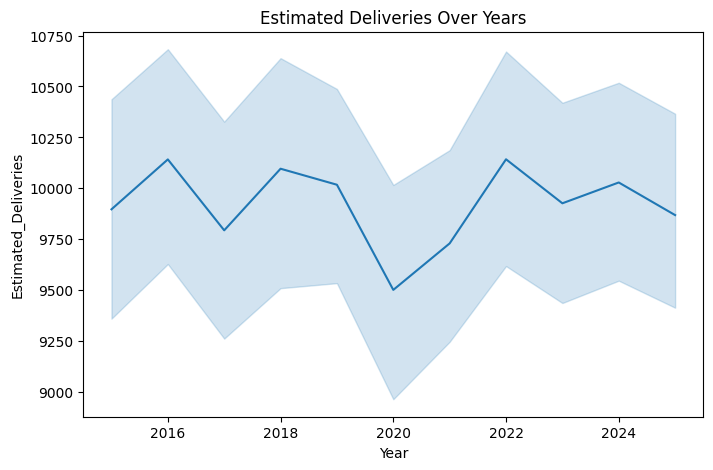

In [79]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x="Year", y="Estimated_Deliveries")
plt.title("Estimated Deliveries Over Years")
plt.show()

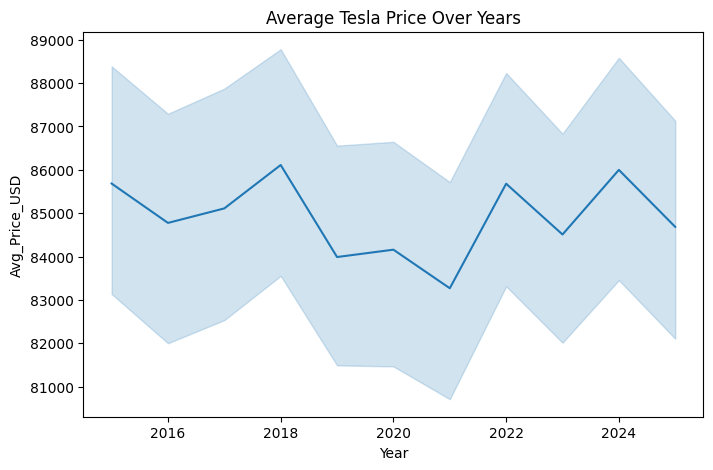

In [80]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x="Year", y="Avg_Price_USD")
plt.title("Average Tesla Price Over Years")
plt.show()

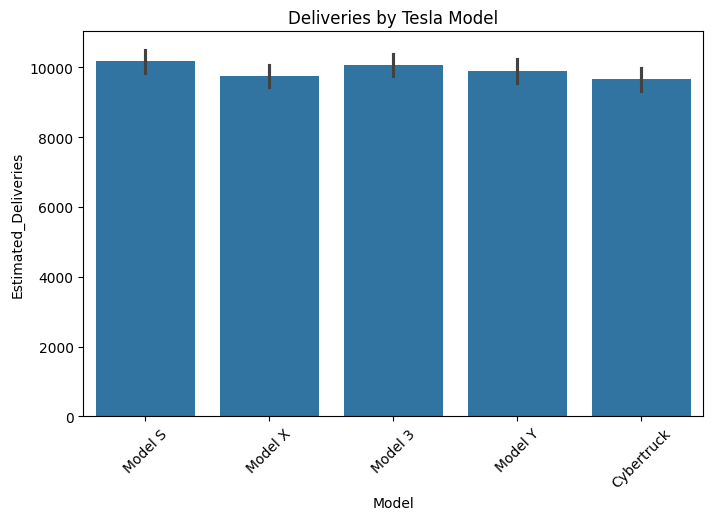

In [81]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Model", y="Estimated_Deliveries")
plt.title("Deliveries by Tesla Model")
plt.xticks(rotation=45)
plt.show()

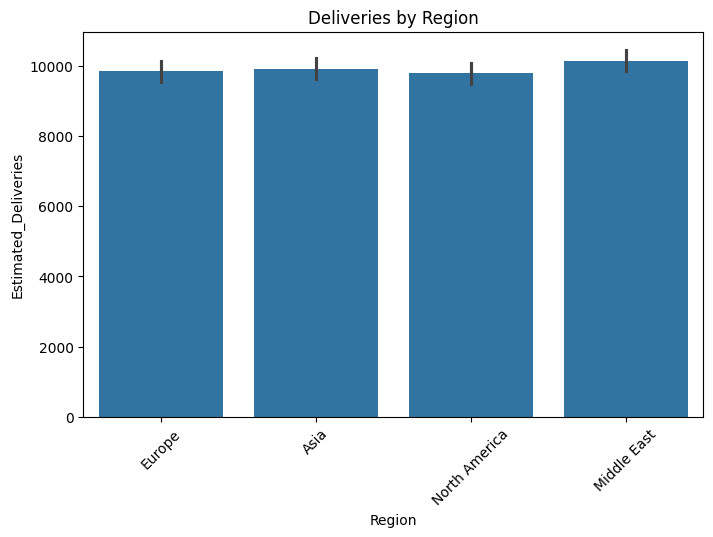

In [82]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Region", y="Estimated_Deliveries")
plt.title("Deliveries by Region")
plt.xticks(rotation=45)
plt.show()

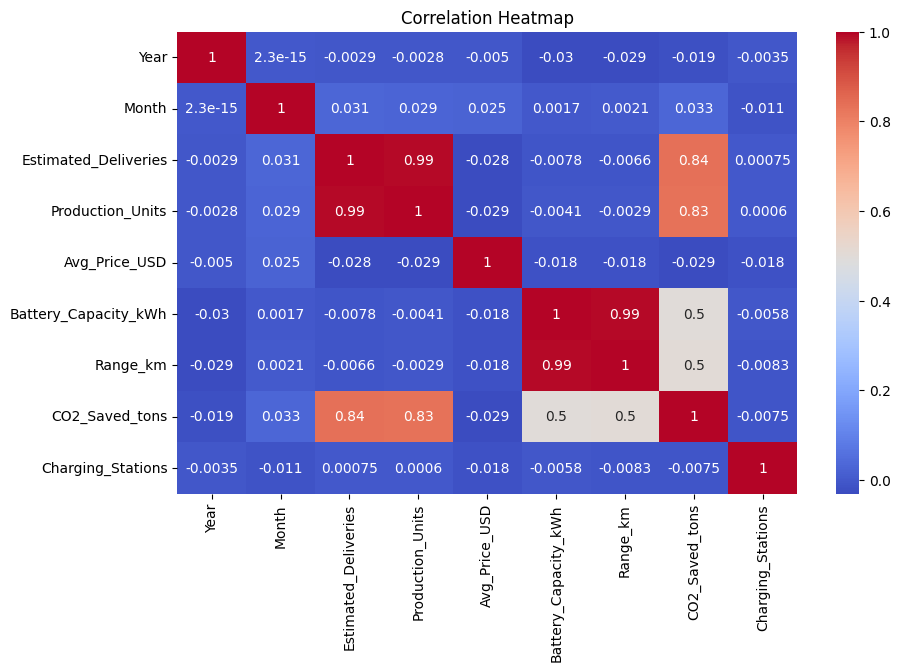

In [83]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Distribution of Numerical Features

Histograms are used to understand the distribution of important numerical variables.

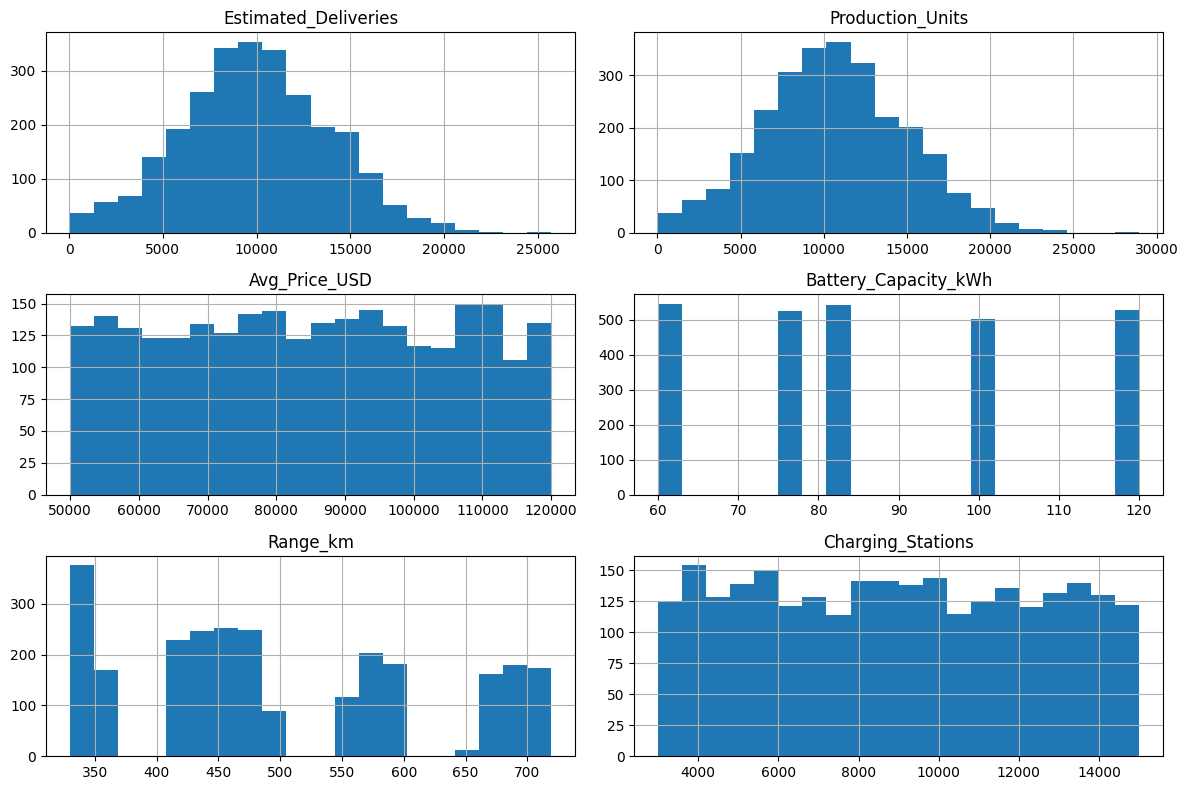

In [108]:
num_cols = [
    "Estimated_Deliveries",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "Charging_Stations"
]

df[num_cols].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

### Outlier Detection

Boxplots are used to identify potential outliers in numerical features.

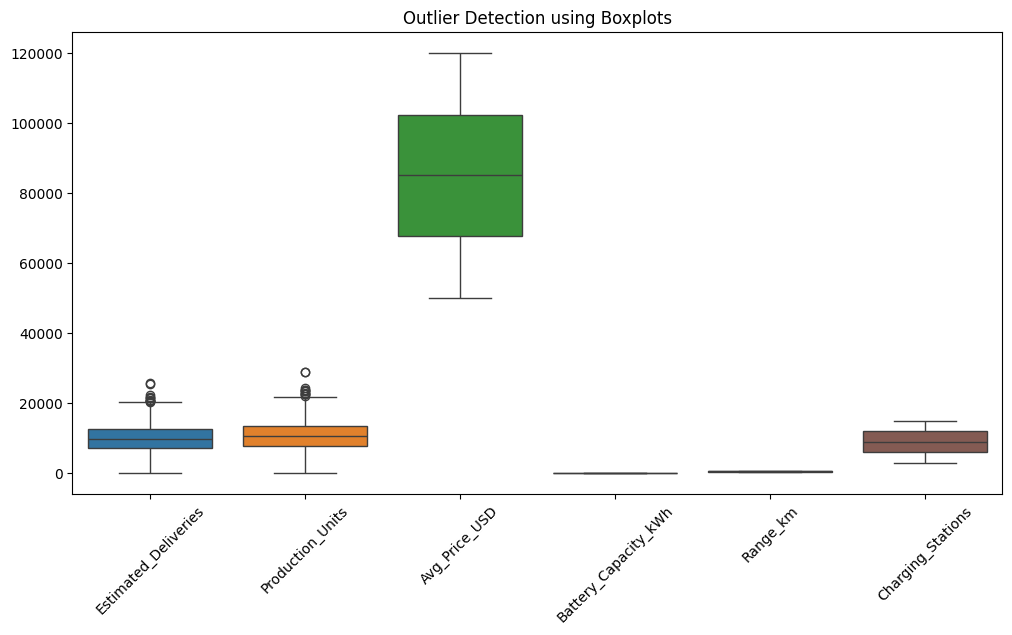

In [109]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[num_cols])

plt.xticks(rotation=45)

plt.title("Outlier Detection using Boxplots")

plt.show()

### Outlier Summary

The number of potential outliers is calculated using the IQR method.

In [110]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Estimated_Deliveries: 12 outliers
Production_Units: 12 outliers
Avg_Price_USD: 0 outliers
Battery_Capacity_kWh: 0 outliers
Range_km: 0 outliers
Charging_Stations: 0 outliers


### Observations

- Numerical features exhibit different distributions across the dataset.
- Boxplots reveal a few extreme values in some variables.
- Since Random Forest models are generally robust to outliers, the observations were retained for modeling.

# 5. Feature Engineering

In this section, we create new useful features from existing columns to improve model performance.

In [84]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [85]:
df["Delivery_Production_Ratio"] = df["Estimated_Deliveries"] / df["Production_Units"]
df["Price_per_kWh"] = df["Avg_Price_USD"] / df["Battery_Capacity_kWh"]
df["Price_per_km_Range"] = df["Avg_Price_USD"] / df["Range_km"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Delivery_Production_Ratio,Price_per_kWh,Price_per_km_Range
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,0.984600,773.952250,131.923679
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,0.911864,829.408667,142.022032
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,0.915334,1437.650244,245.598583
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,0.896594,744.124250,125.414199
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,0.914087,957.056500,173.747020


In [86]:
df = pd.get_dummies(
    df,
    columns=["Region", "Model", "Source_Type"],
    drop_first=True
)

df.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,...,Price_per_km_Range,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,2023-05-01,...,131.923679,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,2015-02-01,...,142.022032,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,2019-01-01,...,245.598583,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,2021-02-01,...,125.414199,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,2016-12-01,...,173.747020,False,True,False,False,False,False,True,False,False


# 6. Regression Modeling

The target variable selected for regression is `Estimated_Deliveries`.

The objective is to predict Tesla vehicle deliveries using production, pricing, battery specifications, regional information, and charging infrastructure data.

In [87]:
X = df.drop(["Estimated_Deliveries", "Date"], axis=1)
y = df["Estimated_Deliveries"]

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [89]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [91]:
print("Linear Regression Results")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression Results
MAE : 108.90909388473658
RMSE : 153.65378896095723
R2 Score : 0.9984161391051817


In [92]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [93]:
print("Random Forest Results")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 67.84397727272729
RMSE : 112.30864434200691
R2 Score : 0.9991538314917368


# 7. Hyperparameter Tuning

Grid Search is used to identify the best Random Forest parameters and improve prediction performance.

In [94]:
param_grid = {
    "n_estimators":[50,100,150],
    "max_depth":[None,5,10],
    "min_samples_split":[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='r2')

In [95]:
print("Best Parameters")
print(grid.best_params_)

Best Parameters
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [96]:
best_model = grid.best_estimator_
tuned_pred = best_model.predict(X_test)

print("Tuned Random Forest Results")
print("MAE :", mean_absolute_error(y_test, tuned_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, tuned_pred)))
print("R2 Score :", r2_score(y_test, tuned_pred))

Tuned Random Forest Results
MAE : 68.53459933893396
RMSE : 109.84878156706922
R2 Score : 0.9991904923141537


# Feature Importance Analysis

Random Forest provides feature importance scores that indicate how much each feature contributes to predicting Tesla vehicle deliveries.

Higher importance values indicate a stronger influence on the model's predictions.

In [111]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,Production_Units,0.990212
8,Delivery_Production_Ratio,0.008705
6,CO2_Saved_tons,0.000281
9,Price_per_kWh,0.000137
1,Month,0.000127
3,Avg_Price_USD,0.000103
7,Charging_Stations,0.000089
10,Price_per_km_Range,0.000079
0,Year,0.000076
5,Range_km,0.000063


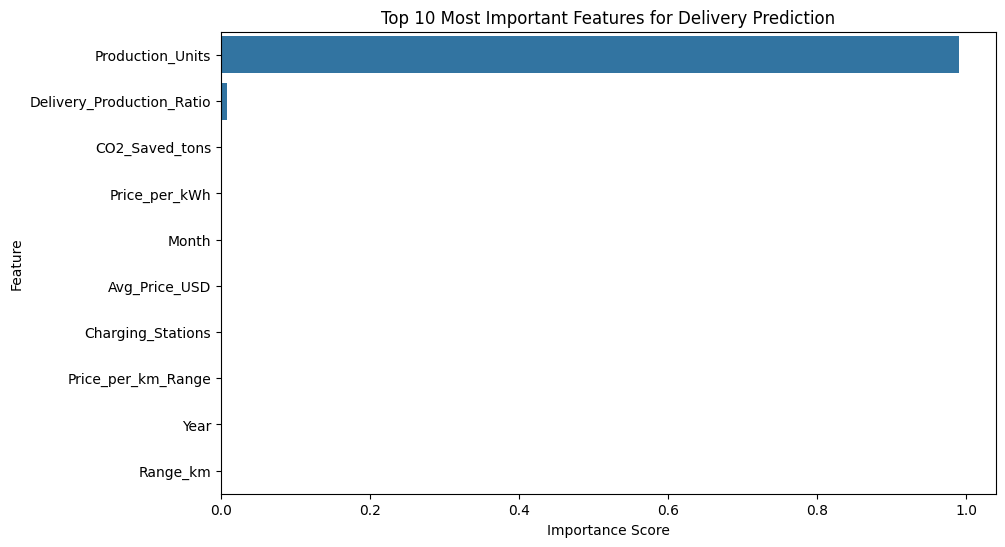

In [112]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features for Delivery Prediction")

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Observations

- Features with higher importance scores have a greater influence on delivery predictions.
- Production volume and historical delivery-related variables are expected to be among the strongest predictors.
- Feature importance helps improve model interpretability and provides insights into the factors affecting Tesla deliveries.

# 8. Time Series Forecasting

A rolling mean was used to smooth short-term fluctuations and visualize delivery trends. ARIMA (AutoRegressive Integrated Moving Average) was then applied to forecast future Tesla deliveries based on historical patterns.

In [97]:
from statsmodels.tsa.arima.model import ARIMA

In [98]:
ts_data = (
    df.groupby("Date")["Estimated_Deliveries"]
    .sum()
    .reset_index()
)

ts_data = ts_data.sort_values("Date")
ts_data.head()

,Date,Estimated_Deliveries
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


In [99]:
ts_data["Rolling_Mean"] = (
    ts_data["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

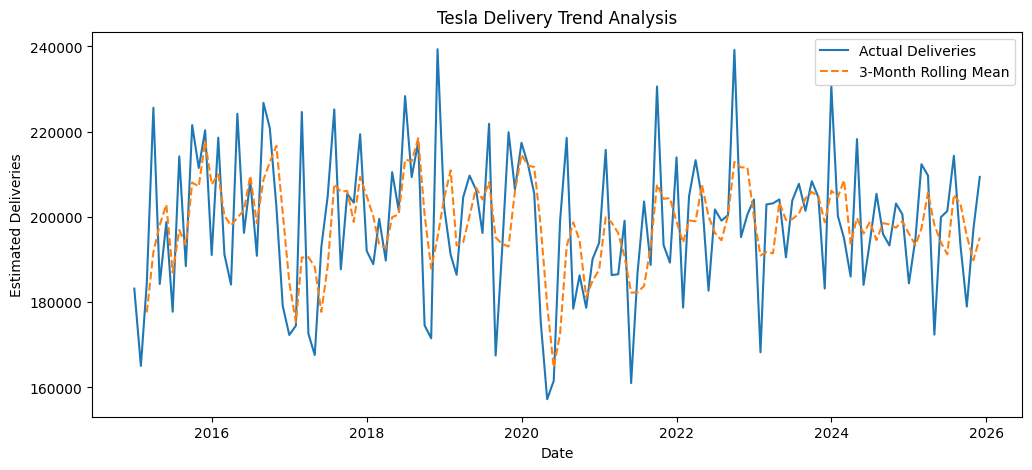

In [100]:
plt.figure(figsize=(12,5))

plt.plot(
    ts_data["Date"],
    ts_data["Estimated_Deliveries"],
    label="Actual Deliveries"
)

plt.plot(
    ts_data["Date"],
    ts_data["Rolling_Mean"],
    label="3-Month Rolling Mean",
    linestyle="--"
)

plt.title("Tesla Delivery Trend Analysis")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

In [101]:
arima_model = ARIMA(
    ts_data["Estimated_Deliveries"],
    order=(2,1,2)
)

arima_fit = arima_model.fit()

In [102]:
forecast = arima_fit.forecast(steps=6)

In [103]:
future_dates = pd.date_range(
    start=ts_data["Date"].max() + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

In [104]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Estimated_Deliveries": forecast.round().astype(int)
})

forecast_df

,Date,Forecasted_Estimated_Deliveries
132,2026-01-01,201435
133,2026-02-01,200329
134,2026-03-01,199802
135,2026-04-01,199649
136,2026-05-01,199597
137,2026-06-01,199580


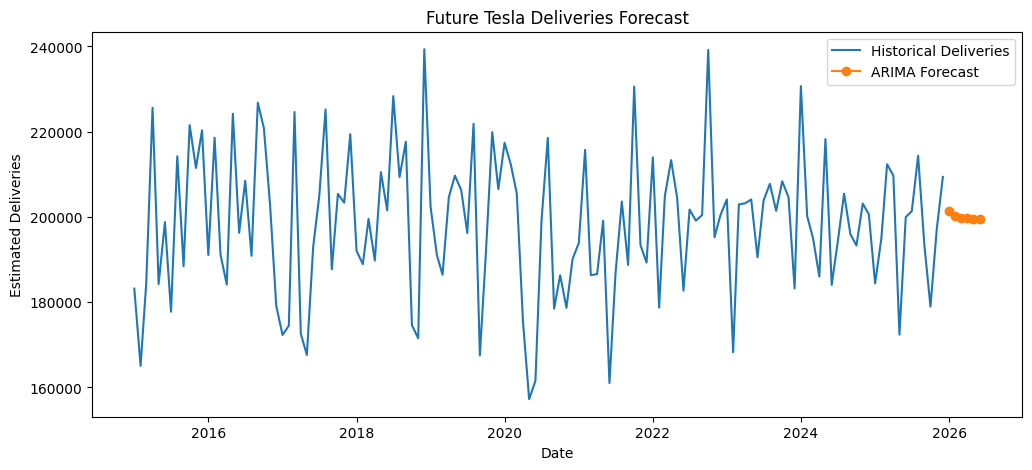

In [105]:
plt.figure(figsize=(12,5))

plt.plot(
    ts_data["Date"],
    ts_data["Estimated_Deliveries"],
    label="Historical Deliveries"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted_Estimated_Deliveries"],
    label="ARIMA Forecast",
    marker="o"
)

plt.title("Future Tesla Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

### Forecasted Future Deliveries

The table below shows the forecasted Tesla vehicle deliveries for the next six months generated using the ARIMA forecasting model.

In [106]:
forecast_df

,Date,Forecasted_Estimated_Deliveries
132,2026-01-01,201435
133,2026-02-01,200329
134,2026-03-01,199802
135,2026-04-01,199649
136,2026-05-01,199597
137,2026-06-01,199580


# Model Evaluation

The table below compares the actual Tesla deliveries with the deliveries predicted by the tuned Random Forest model across different time periods. This helps evaluate the model's prediction accuracy and identify forecasting errors.

In [107]:
comparison_df = pd.DataFrame({
    "Date": df.loc[y_test.index, "Date"],
    "Actual_Estimated_Deliveries": y_test,
    "Predicted_Estimated_Deliveries": tuned_pred.round().astype(int)
})

comparison_df["Difference"] = (
    comparison_df["Actual_Estimated_Deliveries"]
    - comparison_df["Predicted_Estimated_Deliveries"]
)

comparison_df = comparison_df.sort_values("Date")

comparison_df.reset_index(drop=True, inplace=True)

comparison_df.head(10)

,Date,Actual_Estimated_Deliveries,Predicted_Estimated_Deliveries,Difference
0,2015-01-01,4350,4409,-59
1,2015-01-01,13902,13843,59
2,2015-01-01,11325,11278,47
3,2015-01-01,7292,7137,155
4,2015-02-01,18761,18277,484
5,2015-02-01,5325,5328,-3
6,2015-02-01,7191,7140,51
7,2015-02-01,4718,4754,-36
8,2015-03-01,11929,11722,207
9,2015-03-01,3940,4124,-184


# 9. Conclusion

In this project, an end-to-end Machine Learning pipeline was built using Tesla deliveries and production data.

Key tasks completed include:

- Data loading and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression modeling
- Hyperparameter tuning
- Time series forecasting

The models were used to predict `Estimated_Deliveries`, and their performance was evaluated using regression metrics and actual vs predicted comparisons.

Overall, the project demonstrates how Tesla delivery trends can be analyzed and forecasted using Machine Learning techniques.